
**Análise Exploratória da base de dados**

Usamos os dados do dataset obtido do Mendeley Data: https://data.mendeley.com/datasets/pcx7mj68yn/4


Base analisada: **Enquadrado e Centralizado - Versão 1 - Método A**


In [1]:
# Import para interagir com o sistema operacional (listagem de arquivos, diretórios).
import os
# Import para manipulação de arrays e operações numéricas.
import numpy as np
# Import para manipulação e análise de dados tabulares (DataFrames).
import pandas as pd
# Import para abrir, manipular e processar imagens.
from PIL import Image
# Import para contagem eficiente de itens (ex: tamanhos de imagem, modos).
from collections import Counter

In [2]:
# Define o caminho do diretório base do dataset, utilizando Drive do Google.
DATASET_DIR = "/content/drive/MyDrive/Dataset Cocoa Beans/Enquadrado e Centralizado - Versão 1 - Método A"

In [3]:
# Lista todos os arquivos e diretórios dentro do DATASET_DIR. Neste contexto, cada diretório é uma classe.
classes = os.listdir(DATASET_DIR)

# Inicializa um dicionário para armazenar a contagem de imagens por classe.
class_counts = {}
for classe in classes:
    # Constrói o caminho completo para a classe atual.
    class_path = os.path.join(DATASET_DIR, classe)
    # Verifica se o item atual é um diretório (uma classe).
    if os.path.isdir(class_path):
        # Se for um diretório, conta o número de arquivos (imagens) dentro dele e armazena no dicionário.
        class_counts[classe] = len(os.listdir(class_path))
# Exibe o dicionário com a contagem de imagens por classe.
class_counts

{'Agglutinated': 100,
 'Brittle': 100,
 'Compartmentalized_Brown': 100,
 'Compartmentalized_PartiallyPurple': 100,
 'Compartmentalized_Purple': 101,
 'Compartmentalized_Slaty': 100,
 'Compartmentalized_White': 100,
 'Flattened': 101,
 'Moldered': 101,
 'Plated_Brown': 101,
 'Plated_Slaty': 100,
 'Plated_Purple': 101,
 'Plated_White': 100,
 'Plated_PartiallyPurple': 101}

In [4]:
# Visualização de cada classe com as linhas descrevendo a quantidades de imagens.
base = pd.DataFrame(class_counts.items(), columns=['Classe', 'Contagem'])
display(base.head())

,Classe,Contagem
0,Agglutinated,100
1,Brittle,100
2,Compartmentalized_Brown,100
3,Compartmentalized_PartiallyPurple,100
4,Compartmentalized_Purple,101


In [5]:
# Definição da base, correspondendo em 6 classes e 2 colunas
base.shape

(14, 2)

In [6]:
# Visualização da base, 14 linhas (correspondendo às 14 classes de cacau) e 2 colunas ('Classe' e 'Contagem').
display(base)

,Classe,Contagem
0,Agglutinated,100
1,Brittle,100
2,Compartmentalized_Brown,100
3,Compartmentalized_PartiallyPurple,100
4,Compartmentalized_Purple,101
5,Compartmentalized_Slaty,100
6,Compartmentalized_White,100
7,Flattened,101
8,Moldered,101
9,Plated_Brown,101


In [7]:
# Exibir os tipos e valores do DataFrame
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Classe    14 non-null     object
 1   Contagem  14 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 356.0+ bytes


In [8]:
# Visualização das colunas pelo nome.
print(base.columns)

Index(['Classe', 'Contagem'], dtype='object')


In [9]:
# Exibir as colunas númericas e valores estatísticos.
# Linha 2 count: O número de valores não nulos.
# Linha 3 mean: A média dos valores.
# Linha 4 std: O desvio padrão, que mede a dispersão dos dados.
# Linha 5 min: O valor mínimo.
# Linha 6 25%: O primeiro quartil (Q1), ou seja, 25% dos dados estão abaixo deste valor.
# Linha 7 50%: A mediana (Q2), ou seja, 50% dos dados estão abaixo deste valor (também é o segundo quartil).
# Linha 8 75%: O terceiro quartil (Q3), ou seja, 75% dos dados estão abaixo deste valor.
# Linha 9 max: O valor máximo.

display(base.describe())

,Contagem
count,14.000000
mean,100.428571
std,0.513553
min,100.000000
25%,100.000000
50%,100.000000
75%,101.000000
max,101.000000


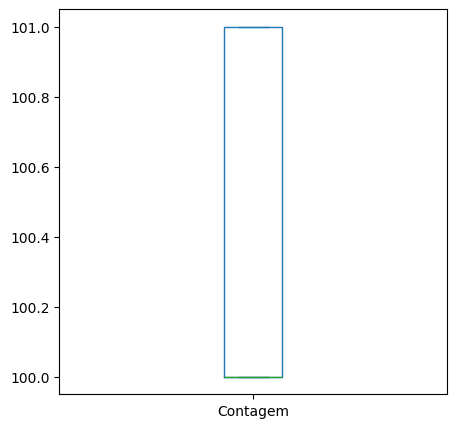

In [10]:
# visualização distribuição dos dados numéricos, mostrando a mediana, os quartis (25% e 75%)
base.plot(kind='box',figsize=(5,5),subplots=True);

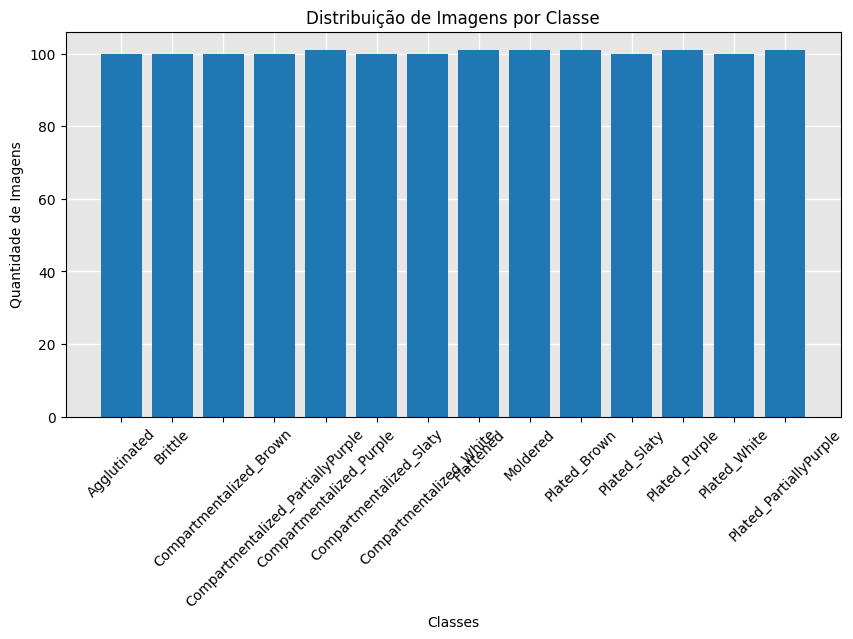

In [11]:
# Import para criação de gráficos e visualizações.
import matplotlib.pyplot as plt
# Gráfico de barras, distribuição das amostras entre as diferentes categorias de grãos de cacau.
plt.figure(figsize=(10,5))
ax = plt.gca()
ax.set_facecolor('#E6E6E6')
plt.grid(True, color='white', linestyle='-', linewidth=1)
ax.set_axisbelow(True)
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Distribuição de Imagens por Classe")
plt.xlabel("Classes")
plt.ylabel("Quantidade de Imagens")
plt.show()

In [12]:
# Lista para armazenar as dimensões (largura, altura) de cada imagem de amostra.
image_sizes = []
# Lista para armazenar o modo de cor (e.g., 'RGB', 'L') de cada imagem de amostra.
image_modes = []

# Import UnidentifiedImageError to handle non-image files gracefully.
from PIL import Image, UnidentifiedImageError

# Iteração sobre cada classe para coletar informações de um subconjunto de imagens.
for classe in classes:
    class_path = os.path.join(DATASET_DIR, classe)
    # Verifica se o item atual é um diretório antes de processá-lo.
    if os.path.isdir(class_path):
        # Iteração sobre as primeiras 20 imagens de cada classe como amostra para análise.
        for img_name in os.listdir(class_path)[:20]:
            img_path = os.path.join(class_path, img_name)
            # Abre a imagem usando a biblioteca PIL.
            try:
                with Image.open(img_path) as img:
                    # Adiciona o tamanho da imagem à lista.
                    image_sizes.append(img.size)
                    # Adiciona o modo de cor da imagem à lista.
                    image_modes.append(img.mode)
            except UnidentifiedImageError:
                print(f"Skipping non-image file: {img_path}")
                continue

# Usa Counter para obter a frequência dos tamanhos e modos de cor encontrados.
# Identificar variações e padrões nas imagens do dataset.
Counter(image_sizes), Counter(image_modes)

Skipping non-image file: /content/drive/MyDrive/Dataset Cocoa Beans/Enquadrado e Centralizado - Versão 1 - Método A/Compartmentalized_Purple/desktop.ini
Skipping non-image file: /content/drive/MyDrive/Dataset Cocoa Beans/Enquadrado e Centralizado - Versão 1 - Método A/Flattened/desktop.ini
Skipping non-image file: /content/drive/MyDrive/Dataset Cocoa Beans/Enquadrado e Centralizado - Versão 1 - Método A/Moldered/desktop.ini
Skipping non-image file: /content/drive/MyDrive/Dataset Cocoa Beans/Enquadrado e Centralizado - Versão 1 - Método A/Plated_Brown/desktop.ini
Skipping non-image file: /content/drive/MyDrive/Dataset Cocoa Beans/Enquadrado e Centralizado - Versão 1 - Método A/Plated_Purple/desktop.ini
Skipping non-image file: /content/drive/MyDrive/Dataset Cocoa Beans/Enquadrado e Centralizado - Versão 1 - Método A/Plated_PartiallyPurple/desktop.ini


(Counter({(1507, 2099): 1,
          (1722, 2131): 1,
          (1971, 1987): 1,
          (1523, 2371): 1,
          (1443, 2147): 1,
          (1427, 2531): 1,
          (2243, 1650): 1,
          (1466, 2083): 1,
          (2195, 2019): 1,
          (2099, 1875): 1,
          (1826, 2035): 1,
          (1603, 2019): 1,
          (1395, 2178): 1,
          (1779, 2146): 1,
          (1843, 2195): 1,
          (1697, 1811): 1,
          (1874, 1843): 1,
          (1859, 1587): 1,
          (1955, 1683): 1,
          (1987, 2482): 1,
          (1555, 1123): 1,
          (978, 1331): 1,
          (1187, 1010): 1,
          (1186, 883): 1,
          (1251, 1490): 1,
          (1331, 1602): 1,
          (1571, 1139): 1,
          (1250, 1426): 1,
          (1075, 1778): 1,
          (2115, 1171): 1,
          (1930, 1379): 1,
          (1747, 1187): 1,
          (1555, 1043): 1,
          (1603, 1027): 1,
          (1075, 1226): 1,
          (1970, 1091): 1,
          (1747, 1250): 1,
   

In [13]:
# Import para contagem eficiente de itens (ex: tamanhos de imagem, modos).
from collections import Counter
# Import para manipulação e análise de dados tabulares (DataFrames).
import pandas as pd

image_size_counts, image_mode_counts = Counter(image_sizes), Counter(image_modes)

# Convertendo a contagem de tamanhos em um DataFrame para melhor visualização.
df_sizes = pd.DataFrame(image_size_counts.items(), columns=['Tamanho da imagem (Largura, Altura)', 'Frequência'])
display(df_sizes.sort_values(by='Frequência', ascending=False).reset_index(drop=True))

# Convertendo a contagem de modos de cor em um DataFrame.
df_modes = pd.DataFrame(image_mode_counts.items(), columns=['Modo de cor', 'Frequência'])
display(df_modes.sort_values(by='Frequência', ascending=False).reset_index(drop=True))

def plot_images_per_class(dataset_dir, classes, samples=5):
    # Cria uma figura para o gráfico e ajusta o tamanho para acomodar a grade de imagens.
    plt.figure(figsize=(15, len(classes)*3))

    # Iteração sobre cada classe para exibir imagens de amostra.
    for idx, classe in enumerate(classes):
        class_path = os.path.join(dataset_dir, classe)
        # Seleciona as primeiras 'samples' imagens de cada classe.
        images = os.listdir(class_path)[:samples]

        # Iteração sobre as imagens selecionadas para a classe atual.
        for i, img_name in enumerate(images):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path) # Abre a imagem.

                # Cria um subplot na grade: (linhas, colunas, posição atual).
                plt.subplot(len(classes), samples, idx*samples + i + 1)
                # Exibe a imagem.
                plt.imshow(img)
                # Remove os eixos para uma visualização mais limpa.
                plt.axis("off")
                # Adiciona o nome da classe como rótulo na primeira imagem de cada linha.
                if i == 0:
                    plt.ylabel(classe, fontsize=12)
            except UnidentifiedImageError:
                print(f"Skipping non-image file in plot: {img_path}")
                continue

    # Ajusta o layout para evitar sobreposição de elementos.
    plt.tight_layout()
    # Exibe o gráfico.
    plt.show()

,"Tamanho da imagem (Largura, Altura)",Frequência
0,"(1251, 2163)",2
1,"(1171, 2499)",2
2,"(1203, 2002)",2
3,"(1171, 2419)",2
4,"(1203, 2211)",2
...,...,...
260,"(1251, 2227)",1
261,"(1234, 2051)",1
262,"(1475, 2626)",1
263,"(1155, 2305)",1


,Modo de cor,Frequência
0,RGB,274


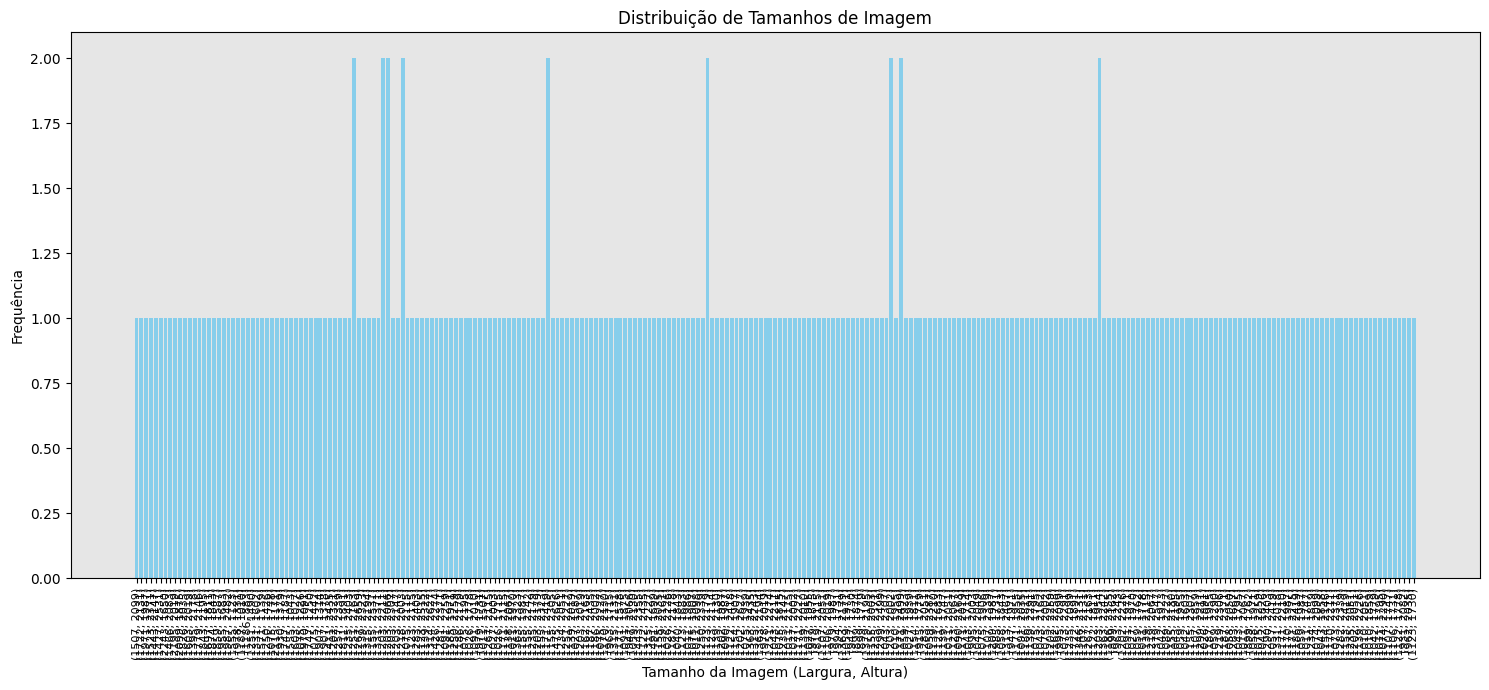

In [14]:
# Import para criação de gráficos e visualizações.
import matplotlib.pyplot as plt

# Gráfico de barras para a distribuição de tamanhos de imagem.
plt.figure(figsize=(15, 7))
ax = plt.gca()
ax.set_facecolor('#E6E6E6')
plt.bar(df_sizes['Tamanho da imagem (Largura, Altura)'].astype(str), df_sizes['Frequência'], color='skyblue')
plt.xlabel('Tamanho da Imagem (Largura, Altura)')
plt.ylabel('Frequência')
plt.title('Distribuição de Tamanhos de Imagem')
plt.xticks(rotation=90, fontsize=8)
# Rotaciona os rótulos do eixo X para melhor legibilidade
plt.tight_layout()
# Ajusta o layout para evitar sobreposição
plt.show()

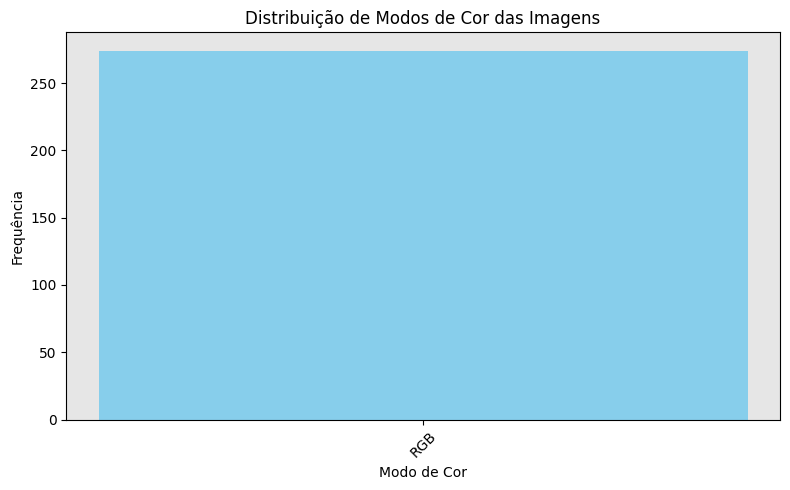

In [15]:
# Gráfico de barras para a distribuição de modos de cor.
plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.set_facecolor('#E6E6E6')
plt.bar(df_modes['Modo de cor'], df_modes['Frequência'], color='skyblue')
plt.xlabel('Modo de Cor')
plt.ylabel('Frequência')
plt.title('Distribuição de Modos de Cor das Imagens')
plt.xticks(rotation=45)
# Rotaciona os rótulos do eixo X, se necessário.
plt.tight_layout()
# Ajusta o layout para evitar sobreposição.
plt.show()

In [16]:
from pathlib import Path
from PIL import Image, UnidentifiedImageError # Import UnidentifiedImageError

# pegar alguns arquivos de exemplo (um por classe)
amostras = []

base_dir_for_images = Path(DATASET_DIR)
actual_image_classes = sorted([d.name for d in base_dir_for_images.iterdir() if d.is_dir()])

for cls in actual_image_classes:
    cls_dir = base_dir_for_images / cls
    # Use next() with a generator expression to find the first actual image file
    first_image = next((f for f in cls_dir.rglob("*") if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff']), None)
    if first_image:
        amostras.append((cls, first_image))
    else:
        print(f"Nenhuma imagem encontrada em {cls_dir}")

larguras = []
alturas = []
formatos = []

for cls, img_path in amostras:
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            larguras.append(w)
            alturas.append(h)
            formatos.append(img.mode)
            print(f"Classe: {cls} | Arquivo: {img_path.name} | Tamanho: {w}x{h} | Modo: {img.mode}")
    except UnidentifiedImageError:
        print(f"Skipping non-image file in samples: {img_path}")
        continue
    except FileNotFoundError:
        print(f"Skipping file not found in samples: {img_path}")
        continue

Classe: Agglutinated | Arquivo: A_001.JPG_p4_v1.JPG | Tamanho: 1507x2099 | Modo: RGB
Classe: Brittle | Arquivo: B_001.JPG_p4_v1.JPG | Tamanho: 1555x1123 | Modo: RGB
Classe: Compartmentalized_Brown | Arquivo: CB_001.JPG_p4_v1.JPG | Tamanho: 1411x2435 | Modo: RGB
Classe: Compartmentalized_PartiallyPurple | Arquivo: CPP_001.JPG_p4_v1.JPG | Tamanho: 1123x2515 | Modo: RGB
Classe: Compartmentalized_Purple | Arquivo: CP_001.JPG_p4_v1.JPG | Tamanho: 1363x2323 | Modo: RGB
Classe: Compartmentalized_Slaty | Arquivo: CS_001.JPG_p4_v1.JPG | Tamanho: 1075x2227 | Modo: RGB
Classe: Compartmentalized_White | Arquivo: CW_001_p4_v1.JPG | Tamanho: 1011x2098 | Modo: RGB
Classe: Flattened | Arquivo: F_001.JPG_p4_v1.JPG | Tamanho: 1011x2115 | Modo: RGB
Classe: Moldered | Arquivo: M_001.JPG_p4_v1.JPG | Tamanho: 1235x2371 | Modo: RGB
Classe: Plated_Brown | Arquivo: PB_002.JPG_p4_v1.JPG | Tamanho: 1043x1714 | Modo: RGB
Classe: Plated_PartiallyPurple | Arquivo: PPP_002.JPG_p4_v1.JPG | Tamanho: 1154x2146 | Modo: 

Skipping non-image file in plot: /content/drive/MyDrive/Dataset Cocoa Beans/Enquadrado e Centralizado - Versão 1 - Método A/Compartmentalized_Purple/desktop.ini
Skipping non-image file in plot: /content/drive/MyDrive/Dataset Cocoa Beans/Enquadrado e Centralizado - Versão 1 - Método A/Flattened/desktop.ini
Skipping non-image file in plot: /content/drive/MyDrive/Dataset Cocoa Beans/Enquadrado e Centralizado - Versão 1 - Método A/Moldered/desktop.ini
Skipping non-image file in plot: /content/drive/MyDrive/Dataset Cocoa Beans/Enquadrado e Centralizado - Versão 1 - Método A/Plated_Brown/desktop.ini
Skipping non-image file in plot: /content/drive/MyDrive/Dataset Cocoa Beans/Enquadrado e Centralizado - Versão 1 - Método A/Plated_PartiallyPurple/desktop.ini
Skipping non-image file in plot: /content/drive/MyDrive/Dataset Cocoa Beans/Enquadrado e Centralizado - Versão 1 - Método A/Plated_Purple/desktop.ini


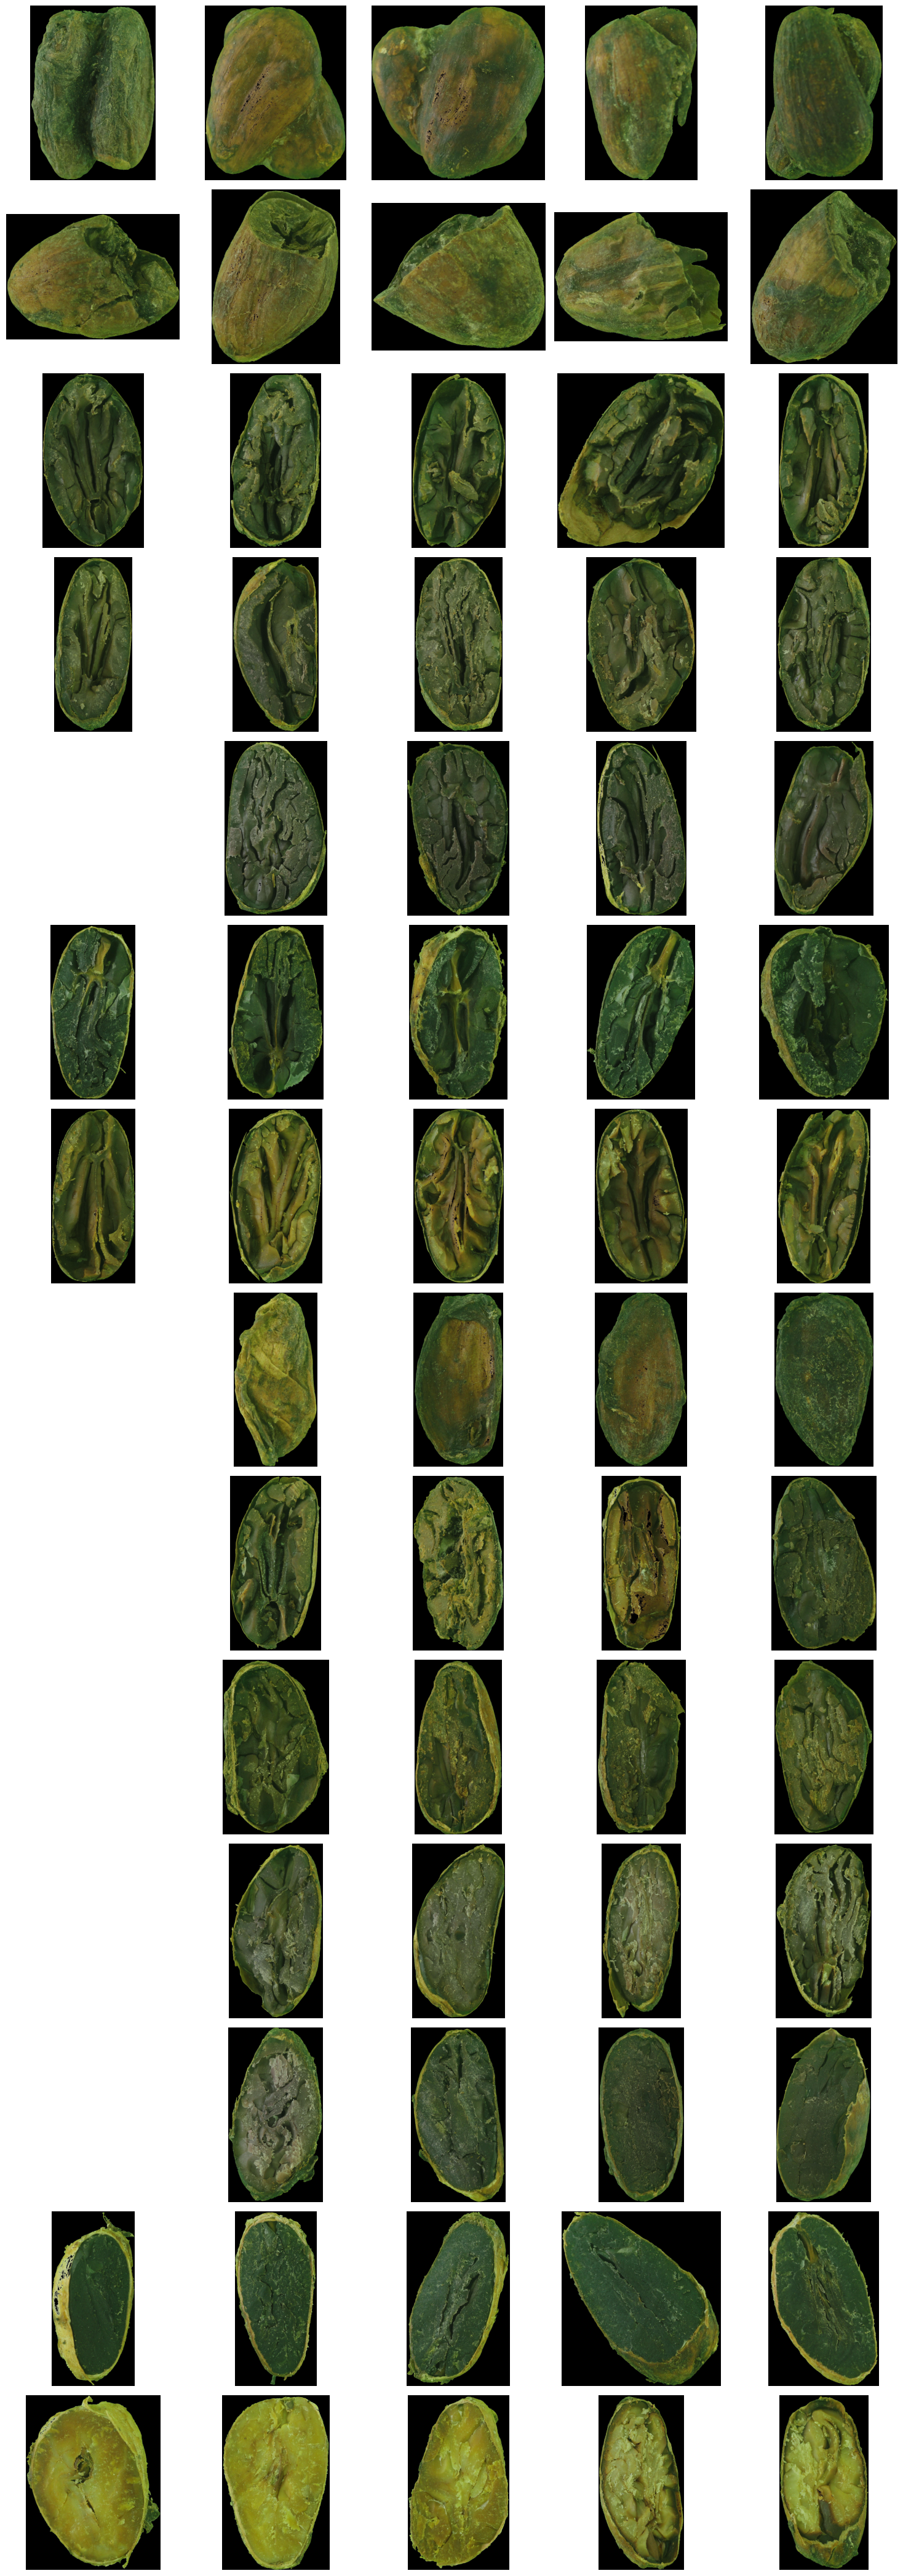

In [17]:
# Gráfico de 5 imagens amostra para cada classe de grão de cacau, dentro de cada categoria.
plot_images_per_class(DATASET_DIR, actual_image_classes, samples=5)